<font>
<div dir=ltr align=center>
<img src='https://cdn.freebiesupply.com/logos/large/2x/sharif-logo-png-transparent.png' width=150 height=150> <br>
<font color=0F5298 size=6>
Natural Language Processing<br>
<font color=2565AE size=4>
Computer Engineering Department<br>
Spring 2025<br>
<font color=3C99D size=4>
Workshop 3 - PyTorch<br>
(Predominantly Adapted from the Spring 2025 Deep Learning Course)<br>
<font color=696880 size=3>
<a href='https://language.ml'>https://language.ml</a><br>
info [AT] language [dot] ml

In [1]:
# !pip install torch torchvision torchaudio

In [2]:
from sched import scheduler

import torch
import math
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# To introduce reproducibility
SEED = 1

# Introduction

In [4]:
my_ndarray = np.array([1, 2, 3, 4.6])

my_ndarray, my_ndarray.dtype, type(my_ndarray)

(array([1. , 2. , 3. , 4.6]), dtype('float64'), numpy.ndarray)

In [5]:
my_tensor = torch.tensor([1, 2, 3, 4.6])

my_tensor, my_tensor.type(), type(my_tensor)

(tensor([1.0000, 2.0000, 3.0000, 4.6000]), 'torch.FloatTensor', torch.Tensor)

In [6]:
my_tensor.numpy(), np.array(my_tensor)

(array([1. , 2. , 3. , 4.6], dtype=float32),
 array([1. , 2. , 3. , 4.6], dtype=float32))

In [7]:
torch.tensor(my_ndarray), torch.from_numpy(my_ndarray)

(tensor([1.0000, 2.0000, 3.0000, 4.6000], dtype=torch.float64),
 tensor([1.0000, 2.0000, 3.0000, 4.6000], dtype=torch.float64))

In [8]:
int_tensor = my_tensor.int()

int_tensor, int_tensor.type()

(tensor([1, 2, 3, 4], dtype=torch.int32), 'torch.IntTensor')

In [9]:
float_tensor = int_tensor.float()

float_tensor, float_tensor.type()

(tensor([1., 2., 3., 4.]), 'torch.FloatTensor')

In [10]:
my_tensor.to(dtype=torch.int64)

tensor([1, 2, 3, 4])

In [11]:
if torch.backends.mps.is_available():
    # Apple's Metal Performance Shaders (MPS) backend
    print('We have mps!')
elif torch.cuda.is_available():
    # NVIDIA CUDA backend
    print('We have cuda!')
else:
    print('Sorry, CPU only.')

We have mps!


In [12]:
device = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
device

'mps'

In [13]:
my_tensor.device

device(type='cpu')

In [14]:
my_tensor = my_tensor.to(device)
my_tensor.device

device(type='mps', index=0)

In [15]:
my_tensor = my_tensor.cpu()
my_tensor.device

device(type='cpu')

In [16]:
try:
    my_tensor = my_tensor.cuda()
    print(my_tensor.device)
except AssertionError:
    print('CUDA is not available on this machine.')

CUDA is not available on this machine.


In [17]:
np_array = np.array([1, 2, 3])
torch_tensor = torch.tensor([1, 2, 3])

np_matrix = np.array([
    [1, 2, 3],
    [3, 4, 5]
])
torch_matrix = torch.tensor([
    [1, 2, 3],
    [3, 4, 5]
])

np_result1 = np.dot(np_matrix, np_array)
np_result2 = np_matrix.dot(np_array)
np_result3 = np_matrix @ np_array

torch_result1 = torch.matmul(torch_matrix, torch_tensor)
torch_result2 = torch_matrix.matmul(torch_tensor)
torch_result3 = torch_matrix @ torch_tensor

print(np_result1)
print(np_result2)
print(np_result3)

print(torch_result1)
print(torch_result2)
print(torch_result3)

[14 26]
[14 26]
[14 26]
tensor([14, 26])
tensor([14, 26])
tensor([14, 26])


In [18]:
np_sum = np.sum(np_array, axis=0)

torch_sum = torch.sum(torch_tensor, dim=0)

print(np_sum)
print(torch_sum)

6
tensor(6)


In [19]:
np_sum = np_matrix.sum(axis=1)

torch_sum = torch_matrix.sum(dim=1)

print(np_sum)
print(torch_sum)

[ 6 12]
tensor([ 6, 12])


In [20]:
z = torch.zeros((5, 3))
z = torch.zeros(5, 3)

print(z)

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])


In [21]:
o = torch.ones((5, 3), dtype=torch.int64)

print(o)

tensor([[1, 1, 1],
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]])


In [22]:
i1 = torch.eye(3, 3)
i2 = torch.eye(3, 4)
i3 = torch.eye(4, 3)

print(i1)
print(i2)
print(i3)

tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])
tensor([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.]])
tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 0., 0.]])


In [23]:
torch.manual_seed(SEED)

# Uniform distribution
torch.rand(2, 2)

tensor([[0.7576, 0.2793],
        [0.4031, 0.7347]])

In [24]:
torch.manual_seed(SEED)

r1 = torch.rand(2, 2)
print('A random tensor:')
print(r1)

r2 = torch.rand(2, 2)
print('\nA different random tensor:')
print(r2)

torch.manual_seed(SEED)
r3 = torch.rand(2, 2)
print('\nShould match r1:')
print(r3)

A random tensor:
tensor([[0.7576, 0.2793],
        [0.4031, 0.7347]])

A different random tensor:
tensor([[0.0293, 0.7999],
        [0.3971, 0.7544]])

Should match r1:
tensor([[0.7576, 0.2793],
        [0.4031, 0.7347]])


In [25]:
ones = torch.zeros(2, 2) + 1
twos = torch.ones(2, 2) * 2
threes = (torch.ones(2, 2) * 7 - 1) / 2
fours = twos ** 2
sqrt2s = twos ** 0.5

print(ones)
print(twos)
print(threes)
print(fours)
print(sqrt2s)

tensor([[1., 1.],
        [1., 1.]])
tensor([[2., 2.],
        [2., 2.]])
tensor([[3., 3.],
        [3., 3.]])
tensor([[4., 4.],
        [4., 4.]])
tensor([[1.4142, 1.4142],
        [1.4142, 1.4142]])


In [26]:
powers2 = twos ** torch.tensor([[1, 2], [3, 4]])
print(powers2)

fives = ones + fours
print(fives)

dozens = threes * fours
print(dozens)

tensor([[ 2.,  4.],
        [ 8., 16.]])
tensor([[5., 5.],
        [5., 5.]])
tensor([[12., 12.],
        [12., 12.]])


In [27]:
new_tensor = torch.tensor([1, 2])
ones + new_tensor

tensor([[2., 3.],
        [2., 3.]])

In [28]:
from IPython.display import display

display(ones + new_tensor)

tensor([[2., 3.],
        [2., 3.]])

In [29]:
print(ones + new_tensor)

tensor([[2., 3.],
        [2., 3.]])


In [30]:
powers2 = twos ** torch.tensor([1, 2])
print(powers2)

tensor([[2., 4.],
        [2., 4.]])


In [31]:
shallow_copy_tensor = ones
deep_copy_tensor = ones.clone()

shallow_copy_tensor[0, 0] = 100

print(ones)
print(shallow_copy_tensor)
print(deep_copy_tensor)

tensor([[100.,   1.],
        [  1.,   1.]])
tensor([[100.,   1.],
        [  1.,   1.]])
tensor([[1., 1.],
        [1., 1.]])


In [32]:
# Boolean Indexing
a = torch.tensor([[1, 2], [3, 4]])
mask = a > 2
print(mask)

result = a[mask]
print(result)

tensor([[False, False],
        [ True,  True]])
tensor([3, 4])


In [33]:
# Example for torch.where
a = torch.tensor([[1, 2], [3, 4]])
b = torch.tensor([[5, 6], [7, 8]])
c = torch.tensor([[9, 10], [11, 12]])

result = torch.where(a > 2, b, c)
print(result)

tensor([[ 9, 10],
        [ 7,  8]])


In [34]:
# Enter . after my_tensor in an IDE to see all the available methods
# my_tensor.

## NN

In [35]:
from torch import nn

In [36]:
nn.ReLU(), nn.Sigmoid(), nn.LogSigmoid

(ReLU(), Sigmoid(), torch.nn.modules.activation.LogSigmoid)

In [37]:
relu = nn.ReLU()

relu.forward(torch.tensor([1])), relu.forward(torch.tensor([-1]))

(tensor([1]), tensor([0]))

In [38]:
nn.Softmax(dim=0)

Softmax(dim=0)

In [39]:
# p: probability of an element to be zeroed
nn.Dropout(p=0.5, inplace=False)

nn.BatchNorm1d(16)

BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

In [40]:
nn.Conv2d(16, 32, 3, stride=1, padding=1)

Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

In [41]:
nn.LSTM(input_size=10, hidden_size=32, num_layers=8, bidirectional=False)

LSTM(10, 32, num_layers=8)

In [42]:
nn.MaxPool2d(2, 2)

nn.AvgPool2d(2, 2)

AvgPool2d(kernel_size=2, stride=2, padding=0)

In [43]:
# Enter . after nn in an IDE to see all the available modules
# nn.

## Loss functions

In [44]:
import torch.nn.functional as F

F.relu(torch.tensor([[1, -2], [0, 4]]))

tensor([[1, 0],
        [0, 4]])

In [45]:
loss = nn.MSELoss()
loss

MSELoss()

In [46]:
x = torch.randn(16, 16)
y = torch.randn(16, 16)

print(loss(x, y), F.mse_loss(x, y))

tensor(2.1246) tensor(2.1246)


In [47]:
loss = nn.CrossEntropyLoss()
loss

CrossEntropyLoss()

In [48]:
torch.manual_seed(SEED)

x = torch.randn(16, 16)
print(x.shape)

y = torch.randn(16, 16).argmax(-1)  # logit
print(y.shape)

torch.Size([16, 16])
torch.Size([16])


In [49]:
print(loss(x, y), F.cross_entropy(x, y))

tensor(3.7683) tensor(3.7683)


In [50]:
loss = nn.BCELoss()
loss

BCELoss()

In [51]:
# We used Sigmoid in order to convert the logits to probabilities
x = torch.randn(16).sigmoid()
y = torch.randn(16, 2).argmax(-1).float()

x, y

(tensor([0.6269, 0.7924, 0.4406, 0.4830, 0.4625, 0.6279, 0.4473, 0.2220, 0.5045,
         0.8044, 0.1488, 0.5282, 0.6113, 0.5782, 0.3340, 0.4297]),
 tensor([0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 0., 0., 1., 0., 1., 0.]))

In [52]:
loss(x, y), F.binary_cross_entropy(x, y)

(tensor(0.7347), tensor(0.7347))

## Gradient

In [53]:
a = torch.linspace(0., 2.*math.pi, steps=25, requires_grad=True)
print(len(a))
print(a)

25
tensor([0.0000, 0.2618, 0.5236, 0.7854, 1.0472, 1.3090, 1.5708, 1.8326, 2.0944,
        2.3562, 2.6180, 2.8798, 3.1416, 3.4034, 3.6652, 3.9270, 4.1888, 4.4506,
        4.7124, 4.9742, 5.2360, 5.4978, 5.7596, 6.0214, 6.2832],
       requires_grad=True)


In [54]:
a.detach()

tensor([0.0000, 0.2618, 0.5236, 0.7854, 1.0472, 1.3090, 1.5708, 1.8326, 2.0944,
        2.3562, 2.6180, 2.8798, 3.1416, 3.4034, 3.6652, 3.9270, 4.1888, 4.4506,
        4.7124, 4.9742, 5.2360, 5.4978, 5.7596, 6.0214, 6.2832])

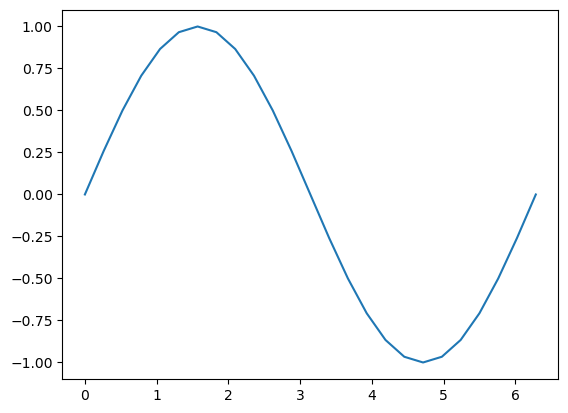

In [55]:
b = torch.sin(a)

plt.plot(a.detach(), b.detach())
plt.show()

tensor([ 1.0000e+00,  9.6593e-01,  8.6603e-01,  7.0711e-01,  5.0000e-01,
         2.5882e-01, -4.3711e-08, -2.5882e-01, -5.0000e-01, -7.0711e-01,
        -8.6603e-01, -9.6593e-01, -1.0000e+00, -9.6593e-01, -8.6603e-01,
        -7.0711e-01, -5.0000e-01, -2.5882e-01,  1.1925e-08,  2.5882e-01,
         5.0000e-01,  7.0711e-01,  8.6603e-01,  9.6593e-01,  1.0000e+00])


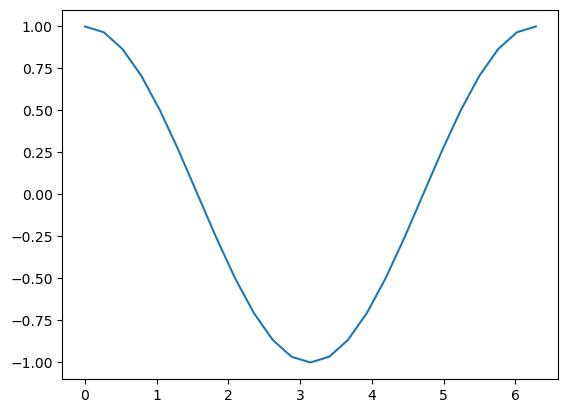

In [56]:
# We used .sum because applying .backward() on a tensor with more than one element will raise an error
out = b.sum()
out.backward()

print(a.grad)
plt.plot(a.detach(), a.grad.detach())

In [57]:
x = torch.tensor([[-1.0], [0.0], [1.0], [2.0], [3.0], [4.0]], dtype=torch.float)
target = torch.tensor([[-3.0], [-1.5], [2.0], [3.0], [4.0], [7.0]], dtype=torch.float)

layer1 = nn.Linear(1, 1, bias=True)
model = nn.Sequential(layer1)

In [58]:
layer1.weight.shape

torch.Size([1, 1])

In [59]:
def init_weights(m):
    if isinstance(m, nn.Linear):
        # xavier is good for relu and sigmoid activation functions
        torch.nn.init.xavier_normal_(m.weight)
        m.bias.data.fill_(0.01)


model.apply(init_weights)

Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
)

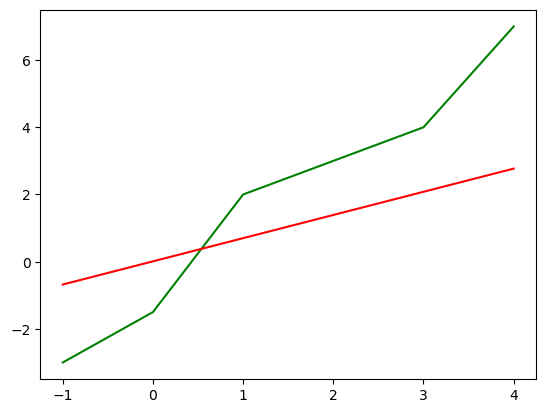

In [60]:
predicted_target = model(x)

plt.plot(x.detach().numpy(), target.detach().numpy(), color='green')
plt.plot(x.detach().numpy(), predicted_target.detach().numpy(), color='red')
plt.show()

In [61]:
loss_fc = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [62]:
def train_model(model, loss_fc, optimizer):
    model.train()
    for epoch in range(500):
        predicted_target = model(x)
        loss = loss_fc(predicted_target, target)
        optimizer.zero_grad()

        loss.backward()
        optimizer.step()
        if epoch % 50 == 0:
            print('Epoch: %d | Loss: %.4f' % (epoch, loss.detach().item()))

    plt.plot(x.detach().numpy(), target.detach().numpy(), color='green')
    plt.plot(x.detach().numpy(), predicted_target.detach().numpy(), color='red')
    plt.show()

Epoch: 0 | Loss: 5.5873
Epoch: 50 | Loss: 0.6712
Epoch: 100 | Loss: 0.4658
Epoch: 150 | Loss: 0.3931
Epoch: 200 | Loss: 0.3673
Epoch: 250 | Loss: 0.3582
Epoch: 300 | Loss: 0.3549
Epoch: 350 | Loss: 0.3538
Epoch: 400 | Loss: 0.3534
Epoch: 450 | Loss: 0.3533


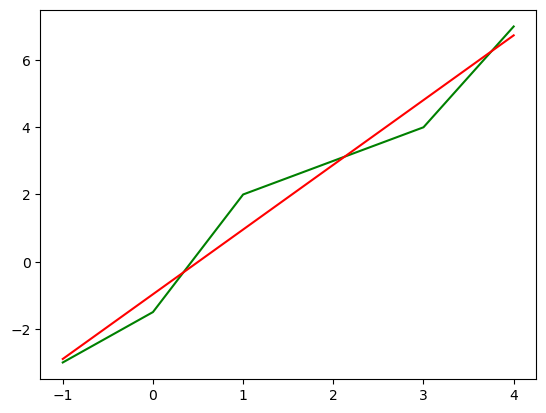

In [63]:
train_model(model, loss_fc, optimizer)

In [64]:
non_linear_model = nn.Sequential(
    nn.Linear(1, 1, bias=True),
    nn.ReLU(),
    nn.Linear(1, 1, bias=True)
)

loss_fc = nn.MSELoss()
optimizer = torch.optim.SGD(non_linear_model.parameters(), lr=0.01)

Epoch: 0 | Loss: 14.9474
Epoch: 50 | Loss: 11.6962
Epoch: 100 | Loss: 11.2670
Epoch: 150 | Loss: 11.2101
Epoch: 200 | Loss: 11.2025
Epoch: 250 | Loss: 11.2015
Epoch: 300 | Loss: 11.2014
Epoch: 350 | Loss: 11.2014
Epoch: 400 | Loss: 11.2014
Epoch: 450 | Loss: 11.2014


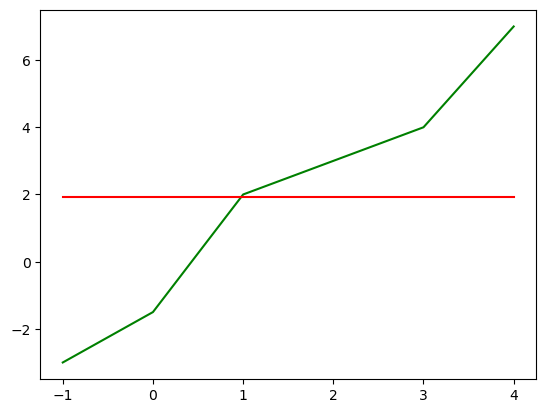

In [65]:
train_model(non_linear_model, loss_fc, optimizer)

# Training Example

In [66]:
import torch
from torchsummary import summary
from torchvision import transforms, datasets
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim.lr_scheduler import LinearLR
from tqdm.notebook import tqdm

In [67]:
transformation = transforms.Compose([
    transforms.Resize(28),
    transforms.ToTensor(),
])

In [68]:
transforms.Grayscale(num_output_channels=3)

transforms.Pad(5, fill=0, padding_mode='constant')

transforms.RandomHorizontalFlip(p=0.5)

transforms.RandomRotation(degrees=(90, -90))

transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

In [69]:
mnist_data = datasets.MNIST(root='data/', download=True, transform=transformation)

print(len(mnist_data))

train_size = int(0.8 * len(mnist_data))
val_size = int(0.1 * len(mnist_data))
test_size = len(mnist_data) - train_size - val_size

train_data, val_data, test_data = random_split(mnist_data, [train_size, val_size, test_size])

60000


In [70]:
class MyDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images.float()
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx].unsqueeze(0)
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [71]:
train_dataset = MyDataset(
    train_data.dataset.data[train_data.indices],
    train_data.dataset.targets[train_data.indices]
)
val_dataset = MyDataset(
    val_data.dataset.data[val_data.indices],
    val_data.dataset.targets[val_data.indices]
)
test_dataset = MyDataset(
    test_data.dataset.data[test_data.indices],
    test_data.dataset.targets[test_data.indices]
)

In [72]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [73]:
from torch import nn

In [74]:
class NetModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(in_channels=8, out_channels=8, kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16, 10),
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)

        return x

In [75]:
md = NetModel()
summary(md, (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 8, 26, 26]              80
              ReLU-2            [-1, 8, 26, 26]               0
            Conv2d-3            [-1, 8, 24, 24]             584
              ReLU-4            [-1, 8, 24, 24]               0
            Conv2d-5           [-1, 16, 22, 22]           1,168
              ReLU-6           [-1, 16, 22, 22]               0
            Conv2d-7           [-1, 16, 20, 20]           2,320
              ReLU-8           [-1, 16, 20, 20]               0
            Conv2d-9           [-1, 16, 18, 18]           2,320
             ReLU-10           [-1, 16, 18, 18]               0
AdaptiveAvgPool2d-11             [-1, 16, 1, 1]               0
          Flatten-12                   [-1, 16]               0
           Linear-13                   [-1, 10]             170
Total params: 6,642
Trainable params: 6

In [76]:
for param in md.parameters():
    param.requires_grad = False

display(summary(md, (1, 28, 28)))

for param in md.parameters():
    param.requires_grad = True

display(summary(md, (1, 28, 28)))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 8, 26, 26]              80
              ReLU-2            [-1, 8, 26, 26]               0
            Conv2d-3            [-1, 8, 24, 24]             584
              ReLU-4            [-1, 8, 24, 24]               0
            Conv2d-5           [-1, 16, 22, 22]           1,168
              ReLU-6           [-1, 16, 22, 22]               0
            Conv2d-7           [-1, 16, 20, 20]           2,320
              ReLU-8           [-1, 16, 20, 20]               0
            Conv2d-9           [-1, 16, 18, 18]           2,320
             ReLU-10           [-1, 16, 18, 18]               0
AdaptiveAvgPool2d-11             [-1, 16, 1, 1]               0
          Flatten-12                   [-1, 16]               0
           Linear-13                   [-1, 10]             170
Total params: 6,642
Trainable params: 0

None

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 8, 26, 26]              80
              ReLU-2            [-1, 8, 26, 26]               0
            Conv2d-3            [-1, 8, 24, 24]             584
              ReLU-4            [-1, 8, 24, 24]               0
            Conv2d-5           [-1, 16, 22, 22]           1,168
              ReLU-6           [-1, 16, 22, 22]               0
            Conv2d-7           [-1, 16, 20, 20]           2,320
              ReLU-8           [-1, 16, 20, 20]               0
            Conv2d-9           [-1, 16, 18, 18]           2,320
             ReLU-10           [-1, 16, 18, 18]               0
AdaptiveAvgPool2d-11             [-1, 16, 1, 1]               0
          Flatten-12                   [-1, 16]               0
           Linear-13                   [-1, 10]             170
Total params: 6,642
Trainable params: 6

None

In [77]:
EPOCHS = 10

model = NetModel().to(device)
criterion = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
# I set end_factor=1.0 because of the simplicity of the task. With lr decay, model can't learn.
scheduler = LinearLR(optimizer, start_factor=1.0, end_factor=1.0, total_iters=EPOCHS)

In [78]:
def train_epoch(model, criterion, optimizer, scheduler, dataloader):
    epoch_loss = 0
    epoch_true = 0
    epoch_all = 0

    model.train()
    progress_bar = tqdm(dataloader)
    for i, (x, y) in enumerate(progress_bar):
        x = x.to(device)
        y = y.to(device)
        preds = model(x)

        loss = criterion(preds, y)

        epoch_loss += float(loss)

        predictions = preds.argmax(-1)
        epoch_all += len(predictions)
        epoch_true += (predictions == y).sum()

        progress_bar.set_description(f'Loss: {epoch_loss / (i + 1):.3e} - Acc: {epoch_true * 100. / epoch_all:.2f}%')
        loss.backward()

        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

In [79]:
def eval_epoch(model, criterion, dataloader):
    epoch_loss = 0
    epoch_true = 0
    epoch_all = 0

    model.eval()
    progress_bar = tqdm(dataloader)
    with torch.no_grad():
        for i, (x, y) in enumerate(progress_bar):
            x = x.to(device)
            y = y.to(device)
            preds = model(x)

            loss = criterion(preds, y)
            epoch_loss += float(loss)

            predictions = preds.argmax(-1)
            epoch_all += len(predictions)
            epoch_true += (predictions == y).sum()

            progress_bar.set_description(f'Loss: {epoch_loss / (i + 1):.3e} - Acc: {epoch_true * 100. / epoch_all:.2f}%')

In [80]:
# Another format of using torch.no_grad
@torch.no_grad()
def test_model(model, criterion, dataloader):
    epoch_loss = 0
    epoch_true = 0
    epoch_all = 0

    model.eval()
    progress_bar = tqdm(dataloader)
    for i, (x, y) in enumerate(progress_bar):
        x = x.to(device)
        y = y.to(device)
        preds = model(x)

        loss = criterion(preds, y)
        epoch_loss += float(loss)

        predictions = preds.argmax(-1)
        epoch_all += len(predictions)
        epoch_true += (predictions == y).sum()

        progress_bar.set_description(f'Loss: {epoch_loss / (i + 1):.3e} - Acc: {epoch_true * 100. / epoch_all:.2f}%')

In [81]:
for _ in range(EPOCHS):
    train_epoch(model, criterion, optimizer, scheduler, train_loader)
    eval_epoch(model, criterion, val_loader)

  0%|          | 0/750 [00:00<?, ?it/s]

  0%|          | 0/94 [00:00<?, ?it/s]

  0%|          | 0/750 [00:00<?, ?it/s]

  0%|          | 0/94 [00:00<?, ?it/s]

  0%|          | 0/750 [00:00<?, ?it/s]

...

  0%|          | 0/94 [00:00<?, ?it/s]

  0%|          | 0/750 [00:00<?, ?it/s]

  0%|          | 0/94 [00:00<?, ?it/s]

  0%|          | 0/750 [00:00<?, ?it/s]

  0%|          | 0/94 [00:00<?, ?it/s]

In [82]:
test_model(model, criterion, test_loader)

  0%|          | 0/94 [00:00<?, ?it/s]